In [ ]:
!git clone https://github.com/lllyasviel/ControlNet
!pip install diffusers transformers accelerate opencv-python
!pip install xformers
!pip install torch==2.0.1

fatal: destination path 'ControlNet' already exists and is not an empty directory.


In [1]:
import cv2
import torch
import numpy as np
from PIL import Image

In [2]:
video_path = "cat.mp4"
cap = cv2.VideoCapture(video_path)

frames = []
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

In [3]:
from google.colab import files
uploaded = files.upload()

Saving cat.mp4 to cat.mp4


In [4]:
import cv2

video_path = "cat.mp4"
cap = cv2.VideoCapture(video_path)

In [5]:
if not cap.isOpened():
    print("Ошибка: видео не открылось")

In [6]:
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps}")
print(f"Кадров: {frame_count}")
print(f"Размер: {width}x{height}")

FPS: 29.97
Кадров: 155
Размер: 1280x720


In [7]:
frames = []

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    frames.append(frame)

cap.release()

print("Извлечено кадров:", len(frames))

Извлечено кадров: 155


In [8]:
step = 2
frames = frames[::step]

In [9]:
resized_frames = []

for frame in frames:
    resized = cv2.resize(frame, (512, 512))
    resized_frames.append(resized)

frames = resized_frames

In [10]:
from PIL import Image

pil_frames = []

for frame in frames:
    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    pil_frames.append(image)

In [11]:
print(len(pil_frames))

78


In [12]:
!pip install diffusers transformers accelerate controlnet_aux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 10.8 MB/s eta 0:00:00


In [13]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via t

In [14]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

In [15]:
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
pipe.enable_xformers_memory_efficient_attention()

In [17]:
canny = CannyDetector()

In [18]:
image = pil_frames[0]
canny_image = canny(image)

In [19]:
import torch
print(torch.cuda.is_available())

True


In [21]:
generator = torch.Generator(device="cuda").manual_seed(42)

In [24]:
prompt = "cyberpunk robotic cat, neon lights, glowing eyes, highly detailed"
negative_prompt = "blurry, low quality, distorted, bad anatomy"

  0%|          | 0/20 [00:00<?, ?it/s]

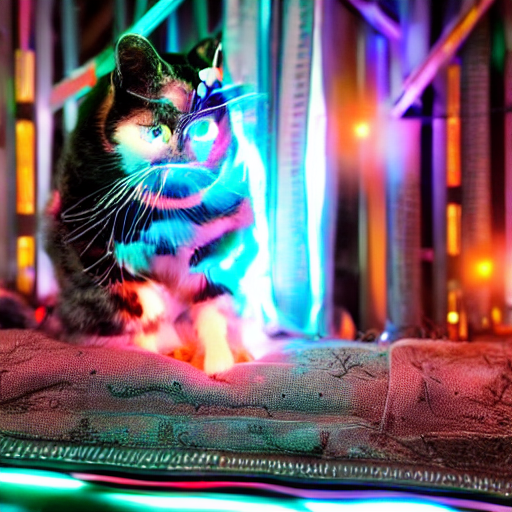

In [25]:
test_result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=canny_image,
    num_inference_steps=20,
    guidance_scale=7,
    controlnet_conditioning_scale=1.0,
    generator=generator
).images[0]

test_result

In [26]:
processed_frames = []

for i, frame in enumerate(pil_frames):

    # 1. Контуры
    canny_image = canny(frame)

    # 2. Генерация
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=canny_image,
        num_inference_steps=20,
        guidance_scale=7,
        controlnet_conditioning_scale=1.0,
        generator=generator
    ).images[0]

    processed_frames.append(result)

    print(f"Готово: {i+1}/{len(pil_frames)}")

  0%|          | 0/20 [00:00<?, ?it/s]

Готово: 1/78


  0%|          | 0/20 [00:00<?, ?it/s]

Готово: 2/78


  0%|          | 0/20 [00:00<?, ?it/s]

...

Готово: 76/78


  0%|          | 0/20 [00:00<?, ?it/s]

Готово: 77/78


  0%|          | 0/20 [00:00<?, ?it/s]

Готово: 78/78


In [27]:
import cv2
import numpy as np

height, width = processed_frames[0].size[1], processed_frames[0].size[0]

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    15,
    (width, height)
)

for frame in processed_frames:
    frame_np = cv2.cvtColor(np.array(frame), cv2.COLOR_RGB2BGR)
    out.write(frame_np)

out.release()

In [28]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>